
# Model Evaluation, Overfitting, Cross-Validation, Bias-Variance, and Regularization

This notebook is a guided demo of core machine learning concepts using **polynomial regression** as an example. We will use synthetic data for clarity.


We begin by importing some useful libraries.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, log_loss
from sklearn.model_selection import train_test_split, KFold, cross_val_score



## 1. Create a synthetic dataset

We will use the following regression example throughout most of the notebook:

$y = sin(\frac{3 \pi}{2}x) + \epsilon$


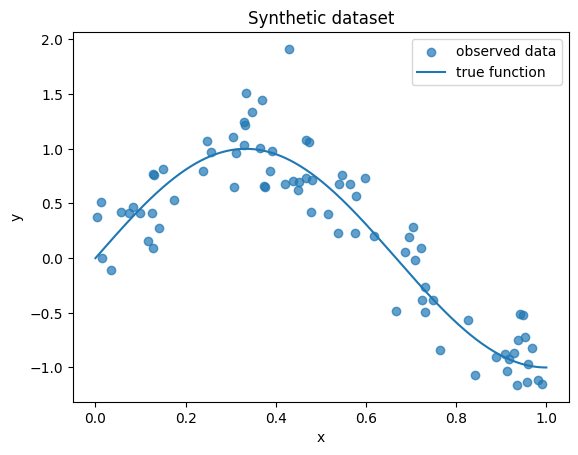

In [ ]:

def true_function(x):
    return np.sin(1.5 * np.pi * x)

n = 80
x = np.sort(np.random.rand(n))
y_true = true_function(x)
y = y_true + np.random.normal(scale=0.25, size=n)

X = x.reshape(-1, 1)

x_grid = np.linspace(0, 1, 400)
X_grid = x_grid.reshape(-1, 1)
y_grid_true = true_function(x_grid)

plt.figure()
plt.scatter(x, y, label='observed data', alpha=0.7)
plt.plot(x_grid, y_grid_true, label='true function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic dataset')
plt.legend()
plt.show()



## 2. Evaluating goodness of a model

We will fit polynomial regression models of different complexity:

- degree 1
- degree 3
- degree 6
- degree 12

We will first look at **training R-squared**. For ordinary least-squares regression,

$R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$

It compares the model to a baseline that always predicts the mean of the observed outcomes.


Degree  1: training R^2 = 0.511
Degree  3: training R^2 = 0.857
Degree  6: training R^2 = 0.876
Degree 20: training R^2 = 0.889


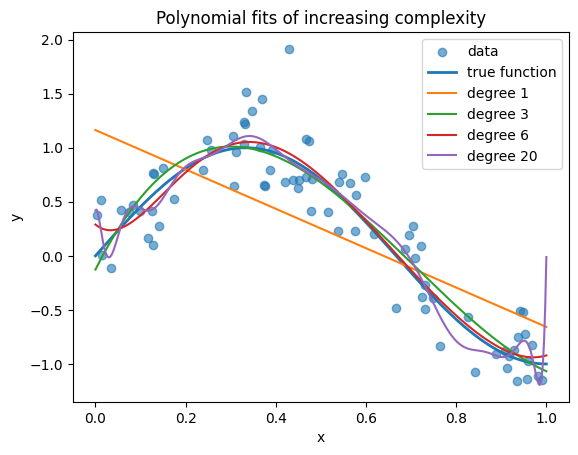

In [ ]:

degrees = [1, 3, 6, 20]

plt.figure()
plt.scatter(x, y, alpha=0.6, label='data')
plt.plot(x_grid, y_grid_true, linewidth=2, label='true function')

for deg in degrees:
    poly = PolynomialFeatures(deg, include_bias=False)
    # fit on training data
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)
    # predict
    yhat = model.predict(X_poly)
    X_grid_poly = poly.transform(X_grid)
    yhat_grid = model.predict(X_grid_poly)
    print(f'Degree {deg:>2}: training R^2 = {r2_score(y, yhat):.3f}')
    plt.plot(x_grid, yhat_grid, label=f'degree {deg}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial fits of increasing complexity')
plt.legend()
plt.show()



As the model gets more complex, training R-squared usually increases. But that does not mean the model is better at predicting new data.



## 3. Overfitting

To check for overfitting, we split the data into a training set and a test set.

- The **training set** is used to fit the model.
- The **test set** is used only to evaluate how well the model generalizes to new data.


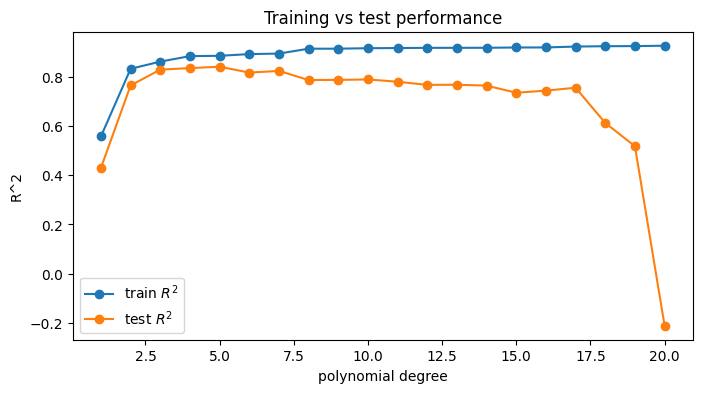

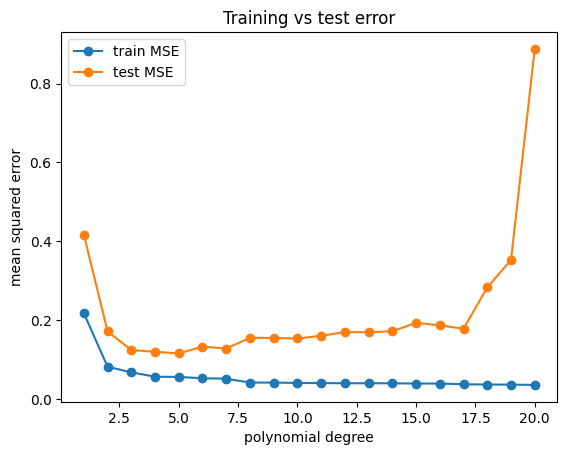

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

degrees = list(range(1, 21))
train_r2 = []
test_r2 = []
train_mse = []
test_mse = []

for deg in degrees:
    # create polynomial features of predictors in the training data
    poly = PolynomialFeatures(deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # fit model on training data
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # 3. predict on train and test data
    yhat_train = model.predict(X_train_poly)
    yhat_test = model.predict(X_test_poly)

    # 4. compute metrics
    train_r2.append(r2_score(y_train, yhat_train))
    test_r2.append(r2_score(y_test, yhat_test))
    train_mse.append(mean_squared_error(y_train, yhat_train))
    test_mse.append(mean_squared_error(y_test, yhat_test))

plt.figure(figsize=(8, 4))
plt.plot(degrees, train_r2, marker='o', label='train $R^2$')
plt.plot(degrees, test_r2, marker='o', label='test $R^2$')
plt.xlabel('polynomial degree')
plt.ylabel('R^2')
plt.title('Training vs test performance')
plt.legend()
plt.show()

plt.figure()
plt.plot(degrees, train_mse, marker='o', label='train MSE')
plt.plot(degrees, test_mse, marker='o', label='test MSE')
plt.xlabel('polynomial degree')
plt.ylabel('mean squared error')
plt.title('Training vs test error')
plt.legend()
plt.show()



- training error keeps going down as complexity increases
- test error improves only up to a point and then gets worse

That worsening is **overfitting**. That means that the model is learning not just the overall pattern but also the quirks of the training sample.



## 4. Visualizing underfitting and overfitting

Let us compare a low-degree, medium-degree, and very high-degree polynomial.


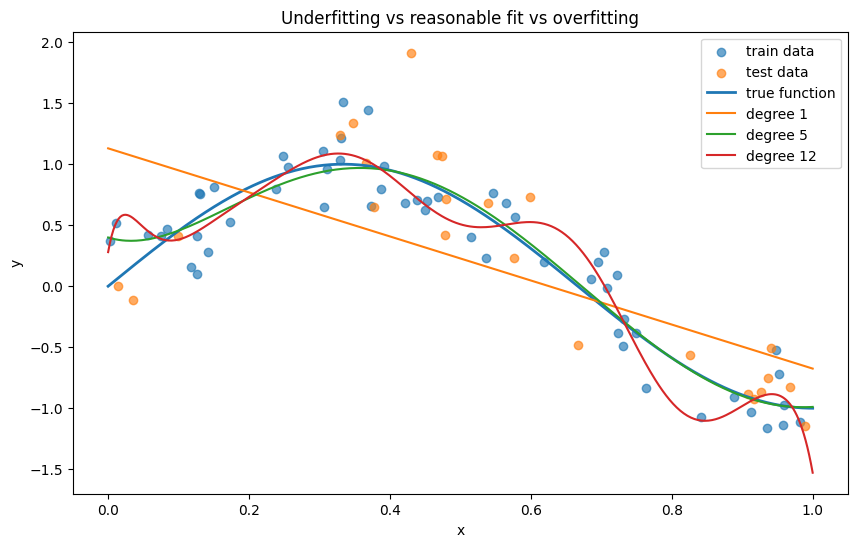

In [ ]:

example_degrees = [1, 5, 12]

plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.65, label='train data')
plt.scatter(X_test[:, 0], y_test, alpha=0.65, label='test data')
plt.plot(x_grid, y_grid_true, linewidth=2, label='true function')

for deg in example_degrees:
    # create polynomial features of predictors in the training data
    poly = PolynomialFeatures(deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    # fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    # predict
    X_grid_poly = poly.transform(X_grid)
    yhat_grid = model.predict(X_grid_poly)
    plt.plot(x_grid, yhat_grid, label=f'degree {deg}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Underfitting vs reasonable fit vs overfitting')
plt.legend()
plt.show()



## 5. A single train/test split can be unstable

One random split may make a model look better or worse just by chance. To show that, we will repeat the train/test split many times and record the test R-squared.


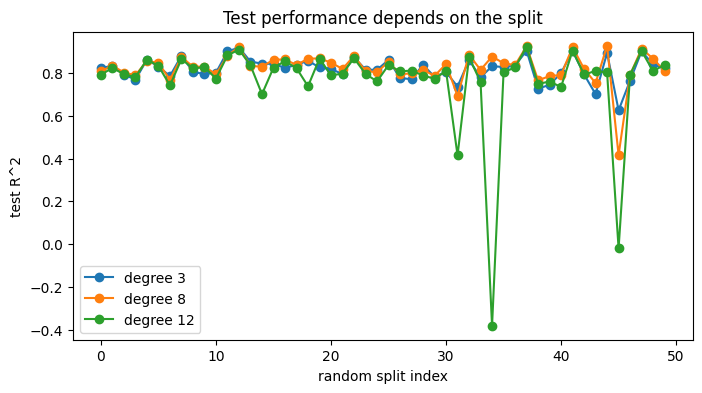

Degree  3: mean test R^2 = 0.818, std = 0.055
Degree  8: mean test R^2 = 0.825, std = 0.075
Degree 12: mean test R^2 = 0.765, std = 0.213


In [ ]:

degrees_to_compare = [3, 8, 12]
results = {d: [] for d in degrees_to_compare}

for seed in range(50):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=seed)
    for deg in degrees_to_compare:
        # 1. create polynomial features from training data
        poly = PolynomialFeatures(deg, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        # 2. fit model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        # 3. predict on test data
        yhat_test = model.predict(X_test_poly)
        # 4. store result
        results[deg].append(r2_score(y_test, yhat_test))

plt.figure(figsize=(8, 4))
for deg in degrees_to_compare:
    plt.plot(results[deg], marker='o', linestyle='-', label=f"degree {deg}")
plt.xlabel("random split index")
plt.ylabel("test R^2")
plt.title("Test performance depends on the split")
plt.legend()
plt.show()

for deg in degrees_to_compare:
    arr = np.array(results[deg])
    print(f"Degree {deg:>2}: mean test R^2 = {arr.mean():.3f}, std = {arr.std():.3f}")



## 6. Cross-validation

A better way to estimate out-of-sample performance is **k-fold cross-validation**:

1. Split the data into $k$ folds.
2. Train on $k-1$ folds.
3. Validate on the remaining fold.
4. Repeat so every fold serves as validation once.
5. Average the scores.

This gives a more stable estimate than relying on lucky or unlucky split.


Best degree by 5-fold CV: 5


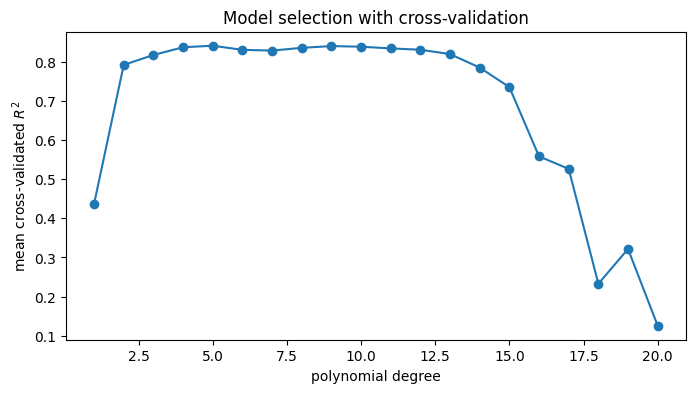

In [ ]:

kf = KFold(n_splits=5, shuffle=True, random_state=0)

degrees = list(range(1, 21))
cv_scores = []

for deg in degrees:
    fold_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # create polynomial features on training fold only
        poly = PolynomialFeatures(deg, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)

        # fit model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # 3. evaluate
        yhat_val = model.predict(X_val_poly)
        fold_scores.append(r2_score(y_val, yhat_val))

    cv_scores.append(np.mean(fold_scores))

best_degree = degrees[int(np.argmax(cv_scores))]
print('Best degree by 5-fold CV:', best_degree)

plt.figure(figsize=(8, 4))
plt.plot(degrees, cv_scores, marker='o')
plt.xlabel('polynomial degree')
plt.ylabel('mean cross-validated $R^2$')
plt.title('Model selection with cross-validation')
plt.show()


Summary:

- **training set**: fit candidate models
- **cross-validation**: choose model complexity or hyperparameters
- **final test set**: estimate final generalization once



## 7. Bias-variance trade-off

Model complexity creates a trade-off:

- **High bias, low variance**: simple models are stable but can miss the true pattern
- **Low bias, high variance**: flexible models can match the training set closely but vary a lot from sample to sample

We will visualize this by repeatedly drawing datasets from the same underlying function.


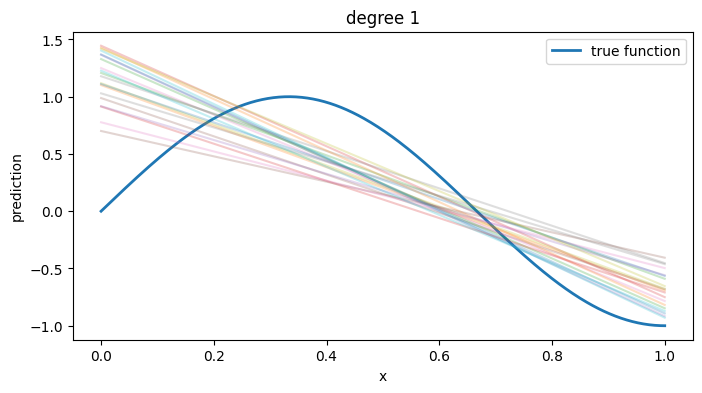

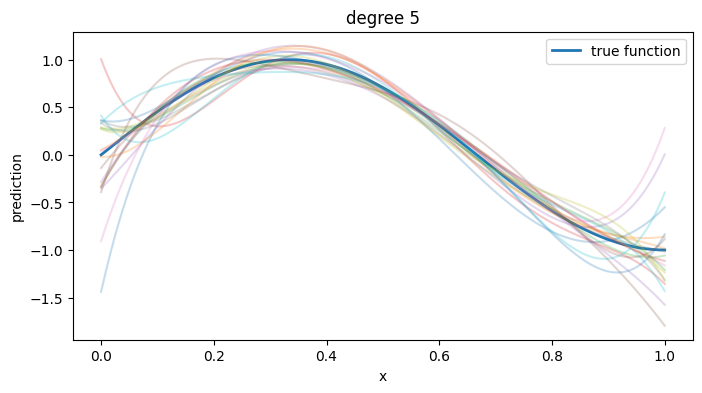

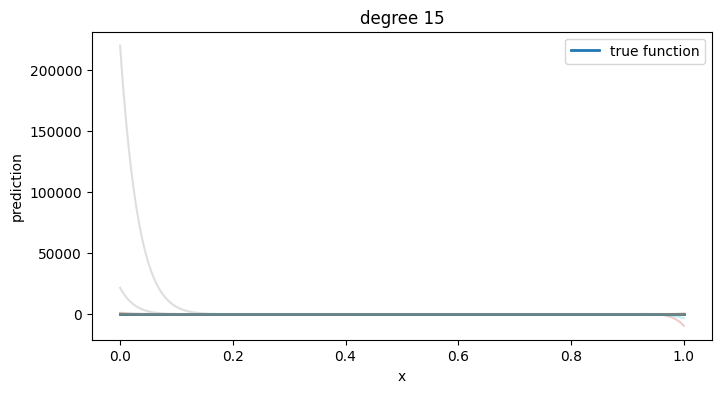

In [ ]:

def sample_dataset(n=30, noise_sd=0.25):
    x = np.sort(np.random.rand(n))
    y = true_function(x) + np.random.normal(scale=noise_sd, size=n)
    return x.reshape(-1, 1), y

x_grid = np.linspace(0, 1, 400)
X_grid = x_grid.reshape(-1, 1)

degrees_to_show = [1, 5, 15]

for deg in degrees_to_show:
    plt.figure(figsize=(8, 4))
    plt.plot(x_grid, true_function(x_grid), linewidth=2, label='true function')
    for _ in range(20):
        X_s, y_s = sample_dataset()
        # create polynomial features on the dataset
        poly = PolynomialFeatures(deg, include_bias=False)
        X_s_poly = poly.fit_transform(X_s)
        # fit model
        model = LinearRegression()
        model.fit(X_s_poly, y_s)
        # predict
        X_grid_poly = poly.transform(X_grid)
        yhat_grid = model.predict(X_grid_poly)
        plt.plot(x_grid, yhat_grid, alpha=0.25)
    plt.title(f'degree {deg}')
    plt.xlabel('x')
    plt.ylabel('prediction')
    plt.legend()
    plt.show()




- Degree 1 often misses the curvature entirely: **high bias**
- Degree 15 may swing wildly across samples: **high variance**



## 8. Regularization

So far, we controlled complexity by changing the polynomial degree. Another way is to keep a flexible model but penalize large coefficients. This is called **regularization**. We will use **ridge regression**, which minimizes:

$\text{loss} = \text{sum of squared errors} + \alpha \sum_j \beta_j^2$

As $\alpha$ increases, the model is forced to be smoother and less flexible.


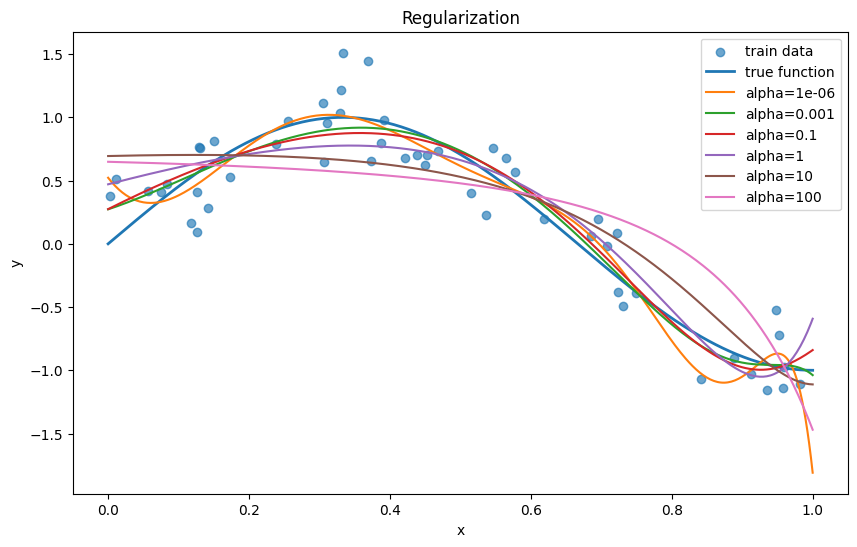

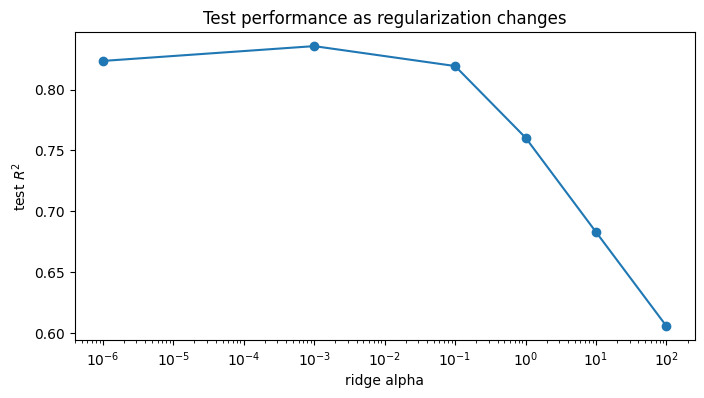

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=0
)

alphas = [1e-6, 1e-3, 1e-1, 1, 10, 100]
ridge_test_r2 = []

plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.65, label="train data")
plt.plot(x_grid, y_grid_true, linewidth=2, label="true function")

for alpha in alphas:
    # create polynomial features
    poly = PolynomialFeatures(15, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_grid_poly = poly.transform(X_grid)

    # scale the predictors (***** important *****)
    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)
    X_grid_poly_scaled = scaler.transform(X_grid_poly)

    # ridge regression
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly_scaled, y_train)

    # evaluate and plot
    yhat_test = model.predict(X_test_poly_scaled)
    ridge_test_r2.append(r2_score(y_test, yhat_test))

    yhat_grid = model.predict(X_grid_poly_scaled)
    plt.plot(x_grid, yhat_grid, label=f'alpha={alpha:g}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Regularization')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, ridge_test_r2, marker='o')
plt.xlabel('ridge alpha')
plt.ylabel('test $R^2$')
plt.title('Test performance as regularization changes')
plt.show()



Regularization:
- makes training fit slightly worse
- improves test performance
- reduces overfitting
